
TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN
---Gradient Check---
 Relative Error: 0.00000007
Gradient is ✅

TEST 2: NUMPY vs PYTORCH
--- local PyTorch vs NumPy Check---
Max difference between NumPy and PyTorch outputs: 0.00000000
✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.

Statring Numpy Training
Epoch 01/15 | Train Loss: 1.7355
Epoch 02/15 | Train Loss: 1.6478
Epoch 03/15 | Train Loss: 1.5902
Epoch 04/15 | Train Loss: 1.5525
Epoch 05/15 | Train Loss: 1.5277
Epoch 06/15 | Train Loss: 1.5109
Epoch 07/15 | Train Loss: 1.4992
Epoch 08/15 | Train Loss: 1.4906
Epoch 09/15 | Train Loss: 1.4838
Epoch 10/15 | Train Loss: 1.4781
Epoch 11/15 | Train Loss: 1.4728
Epoch 12/15 | Train Loss: 1.4675
Epoch 13/15 | Train Loss: 1.4619
Epoch 14/15 | Train Loss: 1.4559
Epoch 15/15 | Train Loss: 1.4494
Numpy Total Training Time: 17.79 seconds

--- Evaluation Results for NumPy RNN ---
Accuracy: 46.69%
Macro-F1 Score: 0.1732

Per-Class F1 Scores:
  Walking: 0.6002
  Jogging: 0.4390
 

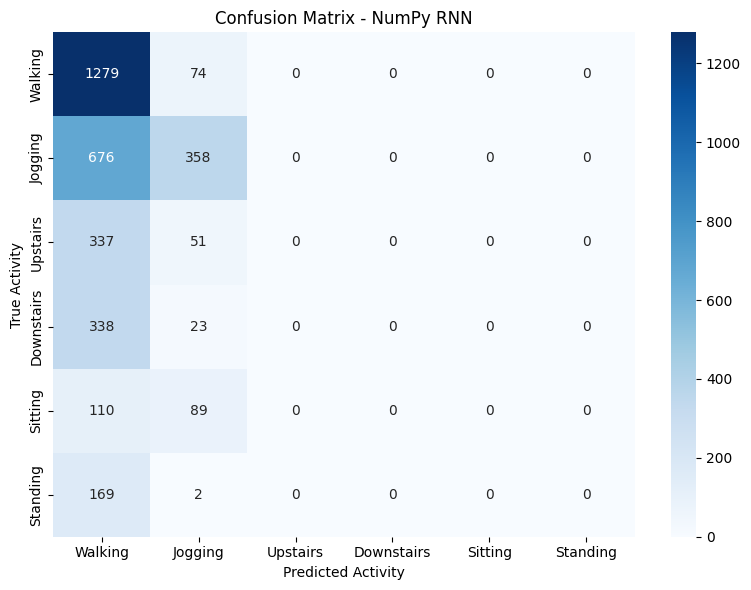


Statring PyTorch Training  PyTorch LSTM
Epoch 01/15 | Train Loss: 1.1309
Epoch 02/15 | Train Loss: 0.8922
Epoch 03/15 | Train Loss: 0.8224
Epoch 04/15 | Train Loss: 0.7404
Epoch 05/15 | Train Loss: 0.6840
Epoch 06/15 | Train Loss: 0.6597
Epoch 07/15 | Train Loss: 0.5638
Epoch 08/15 | Train Loss: 0.5225
Epoch 09/15 | Train Loss: 0.4791
Epoch 10/15 | Train Loss: 0.4585
Epoch 11/15 | Train Loss: 0.4264
Epoch 12/15 | Train Loss: 0.4062
Epoch 13/15 | Train Loss: 0.3549
Epoch 14/15 | Train Loss: 0.4420
Epoch 15/15 | Train Loss: 0.4474
PyTorch Total Training Time PyTorch LSTM: 11.11 seconds

--- Evaluation Results for PyTorch LSTM ---
Accuracy: 75.10%
Macro-F1 Score: 0.6670

Per-Class F1 Scores:
  Walking: 0.8305
  Jogging: 0.8895
  Upstairs: 0.4736
  Downstairs: 0.2759
  Sitting: 0.8603
  Standing: 0.6721


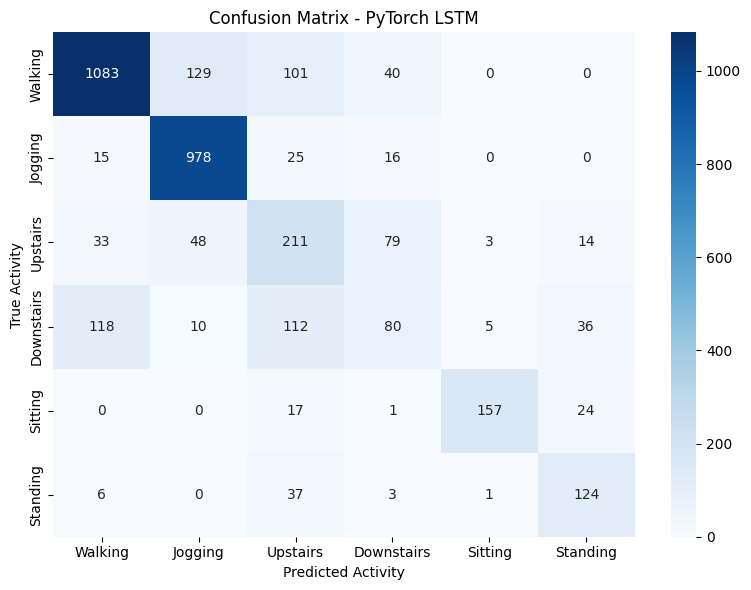


Statring PyTorch Training  PyTorch BiLSTM
Epoch 01/15 | Train Loss: 1.1480
Epoch 02/15 | Train Loss: 0.7817
Epoch 03/15 | Train Loss: 0.6682
Epoch 04/15 | Train Loss: 0.5306
Epoch 05/15 | Train Loss: 0.5111
Epoch 06/15 | Train Loss: 0.4194
Epoch 07/15 | Train Loss: 0.3599
Epoch 08/15 | Train Loss: 0.2847
Epoch 09/15 | Train Loss: 0.2606
Epoch 10/15 | Train Loss: 0.2578
Epoch 11/15 | Train Loss: 0.2054
Epoch 12/15 | Train Loss: 0.1648
Epoch 13/15 | Train Loss: 0.1680
Epoch 14/15 | Train Loss: 0.1415
Epoch 15/15 | Train Loss: 0.1880
PyTorch Total Training Time PyTorch BiLSTM: 47.63 seconds

--- Evaluation Results for PyTorch BiLSTM ---
Accuracy: 80.15%
Macro-F1 Score: 0.7345

Per-Class F1 Scores:
  Walking: 0.8884
  Jogging: 0.8832
  Upstairs: 0.5621
  Downstairs: 0.6454
  Sitting: 0.8225
  Standing: 0.6054


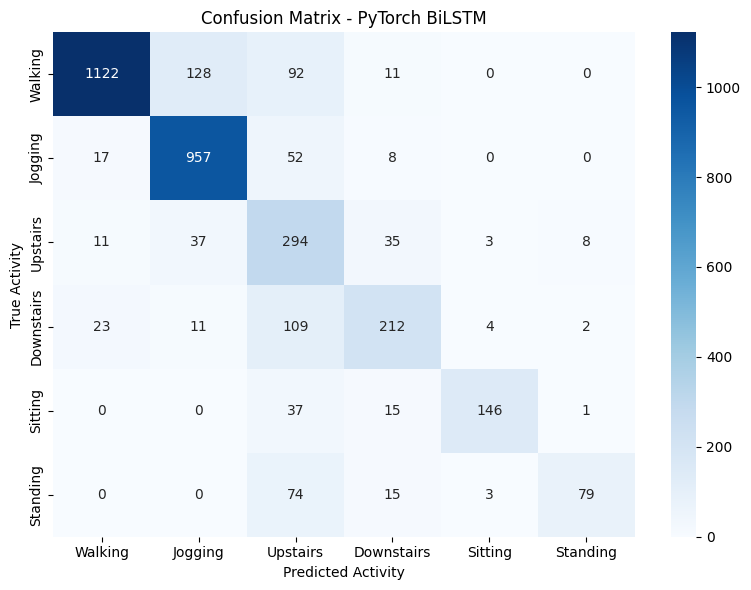


Statring PyTorch Training  PyTorch GRU (Bonus)
Epoch 01/15 | Train Loss: 1.0017
Epoch 02/15 | Train Loss: 0.6209
Epoch 03/15 | Train Loss: 0.4952
Epoch 04/15 | Train Loss: 0.3956
Epoch 05/15 | Train Loss: 0.3370
Epoch 06/15 | Train Loss: 0.2811
Epoch 07/15 | Train Loss: 0.2557
Epoch 08/15 | Train Loss: 0.2250
Epoch 09/15 | Train Loss: 0.1966
Epoch 10/15 | Train Loss: 0.1796
Epoch 11/15 | Train Loss: 0.2007
Epoch 12/15 | Train Loss: 0.1380
Epoch 13/15 | Train Loss: 0.1247
Epoch 14/15 | Train Loss: 0.1170
Epoch 15/15 | Train Loss: 0.1079
PyTorch Total Training Time PyTorch GRU (Bonus): 56.31 seconds

--- Evaluation Results for PyTorch GRU (Bonus) ---
Accuracy: 83.00%
Macro-F1 Score: 0.7972

Per-Class F1 Scores:
  Walking: 0.8776
  Jogging: 0.8835
  Upstairs: 0.6318
  Downstairs: 0.6790
  Sitting: 0.8667
  Standing: 0.8446


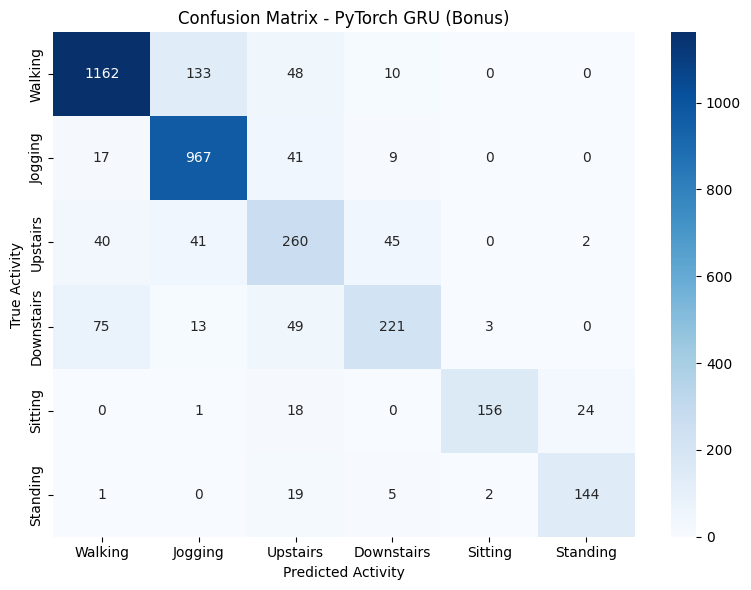


1. NumPy Simple RNN : Time = 17.79s | Accuracy = 46.69% | Macro-F1 = 0.1732
2. PyTorch LSTM     : Time = 11.11s | Accuracy = 75.10% | Macro-F1 = 0.6670
3. PyTorch BiLSTM   : Time = 47.63s | Accuracy = 80.15% | Macro-F1 = 0.7345
4. PyTorch GRU      : Time = 56.31s | Accuracy = 83.00% | Macro-F1 = 0.7972


In [4]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from scipy import stats

torch.set_num_threads(4)
np.random.seed(42)
try:
    FILE_PATH = Path(__file__).resolve().parent
except NameError:
    FILE_PATH = Path.cwd()

ACTIVITY_MAP = {
    "Walking": 0,
    "Jogging": 1,
    "Upstairs": 2,
    "Downstairs": 3,
    "Sitting": 4,
    "Standing": 5,
}
INT_TO_ACTIVITY = {v: k for k, v in ACTIVITY_MAP.items()}


def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)


class NumPyRNN:

    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.lr = learning_rate
        self.hidden_dim = hidden_dim

        scale = 0.01
        self.Wxh = np.random.randn(input_dim, hidden_dim) * scale
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * scale
        self.Wyh = np.random.randn(hidden_dim, output_dim) * scale

        self.bh = np.zeros((1, hidden_dim))
        self.by = np.zeros((1, output_dim))

    def forward(self, X):
        batch_size, window_length, _ = X.shape

        hs = np.zeros((batch_size, window_length + 1, self.hidden_dim))

        for t in range(window_length):
            net_input = X[:, t, :] @ self.Wxh + hs[:, t - 1, :] @ self.Whh + self.bh
            hs[:, t, :] = np.tanh(net_input)

        last_hidden = hs[:, window_length - 1, :]
        logits = last_hidden @ self.Wyh + self.by
        probs = softmax(logits)

        cache = (X, hs, probs)
        return probs, cache

    @staticmethod
    def cross_entropy_loss(probs, y_true):
        epsilon = 1e-12
        n = probs.shape[0]
        correct_probs = probs[np.arange(n), y_true]
        loss = -np.mean(np.log(correct_probs + epsilon))
        return loss

    def backward(self, y_true, cache):
        X, hs, probs = cache
        batch_size, window_length, _ = X.shape

        dlogits = probs.copy()
        dlogits[np.arange(batch_size), y_true] -= 1
        dlogits /= batch_size

        last_hidden = hs[:, window_length - 1, :]
        dWyh = last_hidden.T @ dlogits
        dby = np.sum(dlogits, axis=0, keepdims=True)

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)

        dh_next = dlogits @ self.Wyh.T

        for t in reversed(range(window_length)):
            dtanh = (1 - hs[:, t, :] ** 2) * dh_next

            dWxh += X[:, t, :].T @ dtanh
            dWhh += hs[:, t - 1, :].T @ dtanh
            dbh += np.sum(dtanh, axis=0, keepdims=True)

            dh_next = dtanh @ self.Whh.T

        return {"dWxh": dWxh, "dWhh": dWhh, "dWyh": dWyh, "dbh": dbh, "dby": dby}

    def update_params(self, grads, max_grad_norm=5.0):
        for key in grads:
            grads[key] = np.clip(grads[key], -max_grad_norm, max_grad_norm)

        self.Wxh -= self.lr * grads["dWxh"]
        self.Whh -= self.lr * grads["dWhh"]
        self.Wyh -= self.lr * grads["dWyh"]
        self.bh -= self.lr * grads["dbh"]
        self.by -= self.lr * grads["dby"]


def create_windows(data, window_size=200, step_size=100):

    X_list = []
    Y_list = []

    for _, group in data.groupby("user"):
        features = group[["x", "y", "z"]].values
        activities = group["activity"].values

        for i in range(0, len(group) - window_size + 1, step_size):

            X_list.append(features[i : i + window_size])

            window_labels = activities[i : i + window_size]
            dominant_label = stats.mode(window_labels, keepdims=False)[0]
            Y_list.append(dominant_label)

    return np.array(X_list), np.array(Y_list)


def load_dataset():

    dataset_path = FILE_PATH / "dataset" / "WISDM_ar_v1.1_cleaned.csv"
    dataset = pd.read_csv(
        dataset_path,
        dtype={"user": int, "timestamp": float, "x": float, "y": float, "z": float},
    )
    # print("Dataset Type: " + str(type(dataset)))

    dataset["activity"] = dataset["activity"].map(ACTIVITY_MAP)

    # print("Dataset Head: " + str(dataset.head()))

    train_dataset = dataset[(dataset["user"]) <= 25].copy()
    test_dataset = dataset[dataset["user"] > 25].copy()

    train_features = train_dataset[["x", "y", "z"]].values
    test_features = test_dataset[["x", "y", "z"]].values

    # print("Train Features:\n" + str(train_features[0:10]))

    mean = np.mean(train_features, axis=0)
    std = np.std(train_features, axis=0) + 1e-8  # 1e-8 prevents division by zero

    train_dataset[["x", "y", "z"]] = (train_features - mean) / std

    test_dataset[["x", "y", "z"]] = (test_features - mean) / std

    return dataset, train_dataset, test_dataset


def check_gradient_numerical(model, X_sample, y_sample, epsilon=1e-7):
    print("---Gradient Check---")

    probs, cache = model.forward(X_sample)
    analytic_grads = model.backward(y_sample, cache)
    dWxh_analytic = analytic_grads["dWxh"]

    dWxh_num = np.zeros_like(model.Wxh)

    for i in range(model.Wxh.shape[0]):
        for j in range(model.Wxh.shape[1]):
            orig_val = model.Wxh[i, j]

            model.Wxh[i, j] = orig_val + epsilon
            probs_plus, _ = model.forward(X_sample)
            loss_plus = model.cross_entropy_loss(probs_plus, y_sample)

            model.Wxh[i, j] = orig_val - epsilon
            probs_minus, _ = model.forward(X_sample)
            loss_minus = model.cross_entropy_loss(probs_minus, y_sample)

            dWxh_num[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

            model.Wxh[i, j] = orig_val

    numerator = np.linalg.norm(dWxh_analytic - dWxh_num)
    denominator = np.linalg.norm(dWxh_analytic) + np.linalg.norm(dWxh_num) + 1e-12
    relative_error = numerator / denominator

    print(f" Relative Error: {relative_error:.8f}")
    if relative_error < 1e-5:
        print("Gradient is ✅")
    else:
        print("Gradient is ❌")


def local_Numpy_vs_nnRnn_check(
    numpy_model, input_dim, hidden_dim, batch_size=2, window_len=10
):
    print("--- local PyTorch vs NumPy Check---")

    pytorch_rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

    with torch.no_grad():
        pytorch_rnn.weight_ih_l0.copy_(torch.from_numpy(numpy_model.Wxh.T).float())
        pytorch_rnn.weight_hh_l0.copy_(torch.from_numpy(numpy_model.Whh.T).float())
        pytorch_rnn.bias_ih_l0.copy_(torch.from_numpy(numpy_model.bh.squeeze()).float())
        pytorch_rnn.bias_hh_l0.zero_()

    X_test_np = np.random.randn(batch_size, window_len, input_dim)
    X_test_torch = torch.from_numpy(X_test_np).float()

    _, cache = numpy_model.forward(X_test_np)
    out_numpy = cache[1][:, window_len - 1, :]

    out_torch, _ = pytorch_rnn(X_test_torch)
    out_torch_last = out_torch[:, -1, :].detach().numpy()

    diff = np.max(np.abs(out_numpy - out_torch_last))
    print(f"Max difference between NumPy and PyTorch outputs: {diff:.8f}")
    if diff < 1e-5:
        print("✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.")
    else:
        print("❌ Warning! Significant difference detected between outputs.")


class PyTorchSimpleRNN_Simple(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


class PyTorchLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


class PyTorchBiLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        # Correctly concatenate last forward state (at t=-1) and last backward state (at t=0)
        forward_last = out[:, -1, :self.hidden_dim]
        backward_last = out[:, 0, self.hidden_dim:]
        last_step_out = torch.cat((forward_last, backward_last), dim=1)
        return self.fc(last_step_out)


class PyTorchGRU(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)
        last_step_out = out[:, -1, :]
        return self.fc(last_step_out)


def evaluate_and_report(y_true, y_pred, model_name="Model"):

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(y_true, y_pred, average="macro")

    class_f1 = f1_score(y_true, y_pred, average=None)

    print(f"\n--- Evaluation Results for {model_name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1:.4f}")

    activity_names = [
        "Walking",
        "Jogging",
        "Upstairs",
        "Downstairs",
        "Sitting",
        "Standing",
    ]
    print("\nPer-Class F1 Scores:")
    for name, f1 in zip(activity_names, class_f1):
        print(f"  {name}: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=activity_names,
        yticklabels=activity_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Activity")
    plt.xlabel("Predicted Activity")
    plt.tight_layout()
    plt.show()

    return acc, macro_f1, cm


def train_numpy_rnn(
    model, X_train, y_train, X_test, y_test, epochs=15, batch_size=64, max_grad_norm=5.0
):
    print("\n" + "=" * 60)
    print("Statring Numpy Training")
    print("=" * 60)

    start_time = time.time()
    num_samples = X_train.shape[0]

    for epoch in range(epochs):
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        epoch_loss = 0.0
        num_batches = int(np.ceil(num_samples / batch_size))

        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_samples)

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            probs, cache = model.forward(X_batch)
            loss = model.cross_entropy_loss(probs, y_batch)
            epoch_loss += loss * (end_idx - start_idx)

            grads = model.backward(y_batch, cache)
            model.update_params(grads, max_grad_norm)

        epoch_loss /= num_samples
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"Numpy Total Training Time: {train_time:.2f} seconds")

    test_samples = X_test.shape[0]
    test_batches = int(np.ceil(test_samples / batch_size))
    y_pred_list = []

    for b in range(test_batches):
        start_idx = b * batch_size
        end_idx = min(start_idx + batch_size, test_samples)
        X_batch = X_test[start_idx:end_idx]
        probs, _ = model.forward(X_batch)
        y_pred_list.append(np.argmax(probs, axis=1))

    y_pred = np.concatenate(y_pred_list, axis=0)
    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, "NumPy RNN")
    return train_time, acc, macro_f1


def train_pytorch_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=15,
    batch_size=64,
    lr=0.005,
    model_name="PyTorch Model",
):
    print("\n" + "=" * 60)
    print(f"Statring PyTorch Training  {model_name}")
    print("=" * 60)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    X_test_tensor = torch.from_numpy(X_test).float()

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)

        epoch_loss /= len(train_dataset)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"PyTorch Total Training Time {model_name}: {train_time:.2f} seconds")

    model.eval()
    with torch.no_grad():
        test_outputs = []
        num_test = X_test_tensor.size(0)
        test_batches = int(np.ceil(num_test / batch_size))
        for b in range(test_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_test)
            out = model(X_test_tensor[start_idx:end_idx])
            test_outputs.append(torch.argmax(out, dim=1).numpy())

        y_pred = np.concatenate(test_outputs, axis=0)

    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, model_name)
    return train_time, acc, macro_f1


def main():
    dataset, train_dataset, test_dataset = load_dataset()

    X_train, y_train = create_windows(train_dataset)
    X_test, y_test = create_windows(test_dataset)
    # print("X_train shape:", X_train.shape)
    # print("y_train shape:", y_train.shape)

    input_dim = X_train.shape[2]
    hidden_dim = 32
    output_dim = 6
    learning_rate = 0.01

    numpy_model = NumPyRNN(
        input_dim, hidden_dim, output_dim, learning_rate=learning_rate
    )

    # TEST 1: Numerical Gradient Check (Section 2 Requirement)
    print("\n" + "=" * 60)
    print("TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN")
    print("=" * 60)
    check_gradient_numerical(numpy_model, X_train[:2], y_train[:2])

    # TEST 2: Sanity Check with PyTorch nn.RNN (Section 3 Requirement)
    print("\n" + "=" * 60)
    print("TEST 2: NUMPY vs PYTORCH")
    print("=" * 60)
    local_Numpy_vs_nnRnn_check(
        numpy_model, input_dim, hidden_dim, batch_size=2, window_len=X_train.shape[1]
    )

    # Pytorch training and testing
    numpy_model = NumPyRNN(input_dim, hidden_dim, output_dim, learning_rate=0.01)
    time_np, acc_np, f1_np = train_numpy_rnn(
        numpy_model, X_train, y_train, X_test, y_test, epochs=15
    )

    # LSTM training and testing
    lstm_model = PyTorchLSTM(input_dim, hidden_dim, output_dim)
    time_lstm, acc_lstm, f1_lstm = train_pytorch_model(
        lstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch LSTM",
    )

    # BiLSTM training and testing
    bilstm_model = PyTorchBiLSTM(input_dim, hidden_dim, output_dim)
    time_bilstm, acc_bilstm, f1_bilstm = train_pytorch_model(
        bilstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch BiLSTM",
    )

    # GRU training and testing (Bonus)
    gru_model = PyTorchGRU(input_dim, hidden_dim, output_dim)
    time_gru, acc_gru, f1_gru = train_pytorch_model(
        gru_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch GRU (Bonus)",
    )

    print("\n" + "=" * 70)
    print("=" * 70)
    print(
        f"1. NumPy Simple RNN : Time = {time_np:.2f}s | Accuracy = {acc_np*100:.2f}% | Macro-F1 = {f1_np:.4f}"
    )
    print(
        f"2. PyTorch LSTM     : Time = {time_lstm:.2f}s | Accuracy = {acc_lstm*100:.2f}% | Macro-F1 = {f1_lstm:.4f}"
    )
    print(
        f"3. PyTorch BiLSTM   : Time = {time_bilstm:.2f}s | Accuracy = {acc_bilstm*100:.2f}% | Macro-F1 = {f1_bilstm:.4f}"
    )
    print(
        f"4. PyTorch GRU      : Time = {time_gru:.2f}s | Accuracy = {acc_gru*100:.2f}% | Macro-F1 = {f1_gru:.4f}"
    )
    print("=" * 70)


if __name__ == "__main__":
    main()


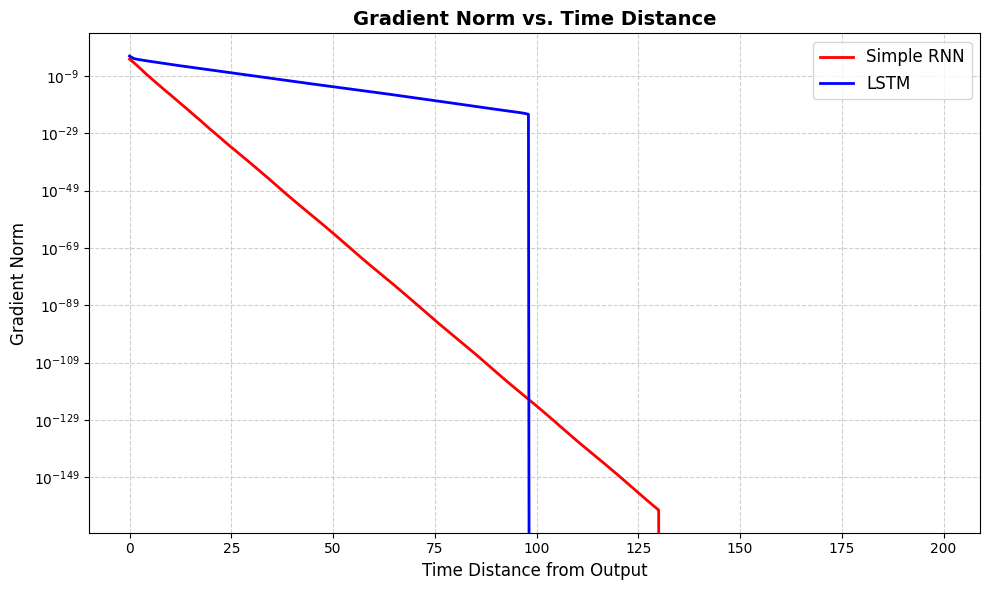

In [5]:
def plot_gradient_norms(numpy_rnn_model, pytorch_lstm_model, X_sample, y_sample):
    window_length = X_sample.shape[1]

    probs, cache = numpy_rnn_model.forward(X_sample)
    X, hs, _ = cache
    batch_size = X_sample.shape[0]

    dlogits = probs.copy()
    dlogits[np.arange(batch_size), y_sample] -= 1
    dlogits /= batch_size

    dh_next = dlogits @ numpy_rnn_model.Wyh.T
    rnn_grad_norms = []

    for t in reversed(range(window_length)):
        norm_val = np.mean(np.linalg.norm(dh_next, axis=-1))
        rnn_grad_norms.append(norm_val)

        dtanh = (1 - hs[:, t, :] ** 2) * dh_next
        dh_next = dtanh @ numpy_rnn_model.Whh.T

    time_distances = np.arange(window_length)

    pytorch_lstm_model.eval()
    pytorch_lstm_model.zero_grad()

    X_tensor = torch.from_numpy(X_sample).float()
    y_tensor = torch.from_numpy(y_sample).long()

    batch_size, _, input_dim = X_tensor.shape
    hidden_dim = pytorch_lstm_model.lstm.hidden_size

    lstm_cell = nn.LSTMCell(input_dim, hidden_dim)
    lstm_cell.weight_ih.data = pytorch_lstm_model.lstm.weight_ih_l0.data
    lstm_cell.weight_hh.data = pytorch_lstm_model.lstm.weight_hh_l0.data
    lstm_cell.bias_ih.data = pytorch_lstm_model.lstm.bias_ih_l0.data
    lstm_cell.bias_hh.data = pytorch_lstm_model.lstm.bias_hh_l0.data

    hx = torch.zeros(batch_size, hidden_dim)
    cx = torch.zeros(batch_size, hidden_dim)

    hidden_states = []
    for t in range(window_length):
        hx, cx = lstm_cell(X_tensor[:, t, :], (hx, cx))
        hx.retain_grad()
        hidden_states.append(hx)

    logits = pytorch_lstm_model.fc(hidden_states[-1])
    loss = nn.CrossEntropyLoss()(logits, y_tensor)
    loss.backward()

    lstm_grad_norms_step = [
        np.mean(np.linalg.norm(h.grad.detach().numpy(), axis=-1)) for h in hidden_states
    ]
    lstm_grad_norms = lstm_grad_norms_step[::-1]

    plt.figure(figsize=(10, 6))
    plt.plot(
        time_distances, rnn_grad_norms, label="Simple RNN", color="red", linewidth=2
    )
    plt.plot(time_distances, lstm_grad_norms, label="LSTM", color="blue", linewidth=2)

    plt.title("Gradient Norm vs. Time Distance", fontsize=14, fontweight="bold")
    plt.xlabel("Time Distance from Output", fontsize=12)
    plt.ylabel("Gradient Norm", fontsize=12)

    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


dataset, train_dataset, test_dataset = load_dataset()
X_train, y_train = create_windows(train_dataset)

input_dim = X_train.shape[2]
hidden_dim = 32
output_dim = 6

numpy_model = NumPyRNN(input_dim, hidden_dim, output_dim, learning_rate=0.01)
lstm_model = PyTorchLSTM(input_dim, hidden_dim, output_dim)

sample_batch_size = 64
X_sample_batch = X_train[:sample_batch_size]
y_sample_batch = y_train[:sample_batch_size]

plot_gradient_norms(numpy_model, lstm_model, X_sample_batch, y_sample_batch)


EXPERIMENT 1: Effect of Window Length (T)

Statring PyTorch Training  LSTM (T=10)
Epoch 01/10 | Train Loss: 0.5644
Epoch 02/10 | Train Loss: 0.3720
Epoch 03/10 | Train Loss: 0.3181
Epoch 04/10 | Train Loss: 0.2889
Epoch 05/10 | Train Loss: 0.2696
Epoch 06/10 | Train Loss: 0.2563
Epoch 07/10 | Train Loss: 0.2457
Epoch 08/10 | Train Loss: 0.2383
Epoch 09/10 | Train Loss: 0.2320
Epoch 10/10 | Train Loss: 0.2268
PyTorch Total Training Time LSTM (T=10): 30.34 seconds

--- Evaluation Results for LSTM (T=10) ---
Accuracy: 75.48%
Macro-F1 Score: 0.7212

Per-Class F1 Scores:
  Walking: 0.8071
  Jogging: 0.8636
  Upstairs: 0.4528
  Downstairs: 0.5440
  Sitting: 0.8896
  Standing: 0.7701


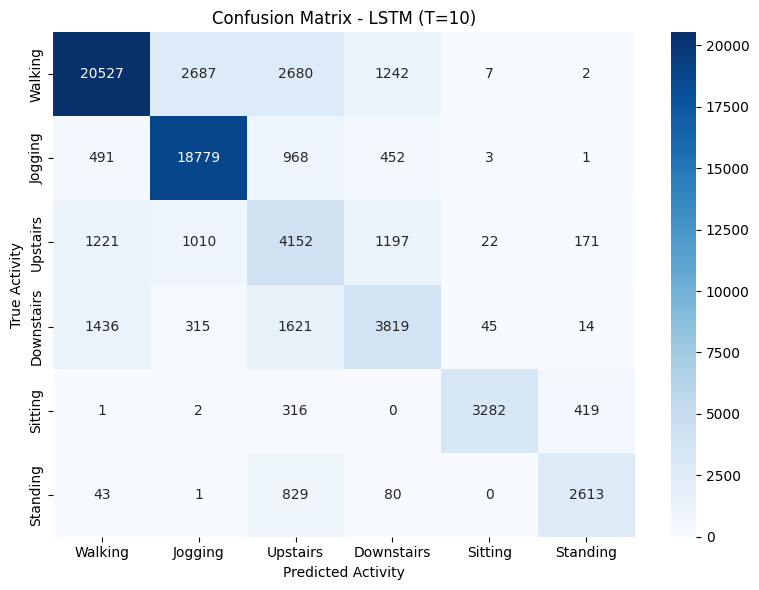


Statring PyTorch Training  LSTM (T=25)
Epoch 01/10 | Train Loss: 0.6136
Epoch 02/10 | Train Loss: 0.3198
Epoch 03/10 | Train Loss: 0.2321
Epoch 04/10 | Train Loss: 0.1973
Epoch 05/10 | Train Loss: 0.1726
Epoch 06/10 | Train Loss: 0.1570
Epoch 07/10 | Train Loss: 0.1435
Epoch 08/10 | Train Loss: 0.1339
Epoch 09/10 | Train Loss: 0.1253
Epoch 10/10 | Train Loss: 0.1197
PyTorch Total Training Time LSTM (T=25): 15.96 seconds

--- Evaluation Results for LSTM (T=25) ---
Accuracy: 81.62%
Macro-F1 Score: 0.7834

Per-Class F1 Scores:
  Walking: 0.8600
  Jogging: 0.8982
  Upstairs: 0.5836
  Downstairs: 0.6458
  Sitting: 0.8893
  Standing: 0.8235


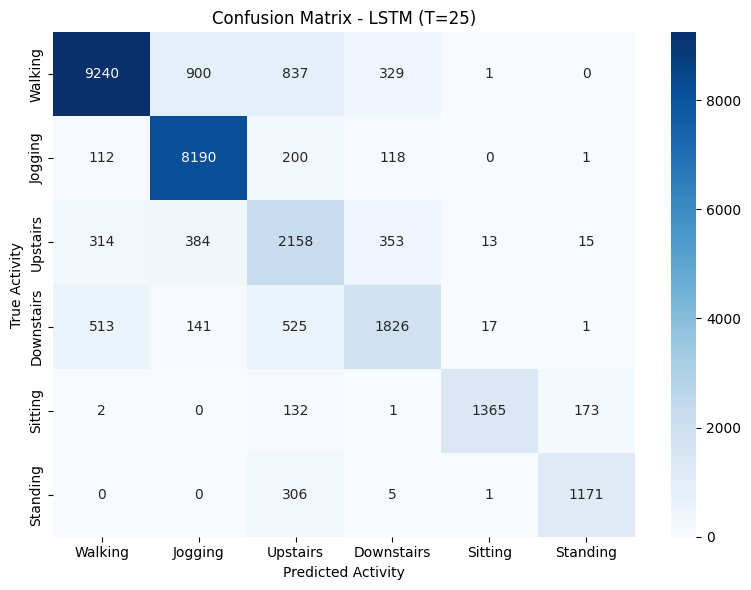


Statring PyTorch Training  LSTM (T=50)
Epoch 01/10 | Train Loss: 0.8492
Epoch 02/10 | Train Loss: 0.5192
Epoch 03/10 | Train Loss: 0.3673
Epoch 04/10 | Train Loss: 0.2795
Epoch 05/10 | Train Loss: 0.2287
Epoch 06/10 | Train Loss: 0.1814
Epoch 07/10 | Train Loss: 0.1604
Epoch 08/10 | Train Loss: 0.1401
Epoch 09/10 | Train Loss: 0.1269
Epoch 10/10 | Train Loss: 0.1139
PyTorch Total Training Time LSTM (T=50): 11.03 seconds

--- Evaluation Results for LSTM (T=50) ---
Accuracy: 84.17%
Macro-F1 Score: 0.7954

Per-Class F1 Scores:
  Walking: 0.8928
  Jogging: 0.9097
  Upstairs: 0.6482
  Downstairs: 0.6969
  Sitting: 0.8467
  Standing: 0.7779


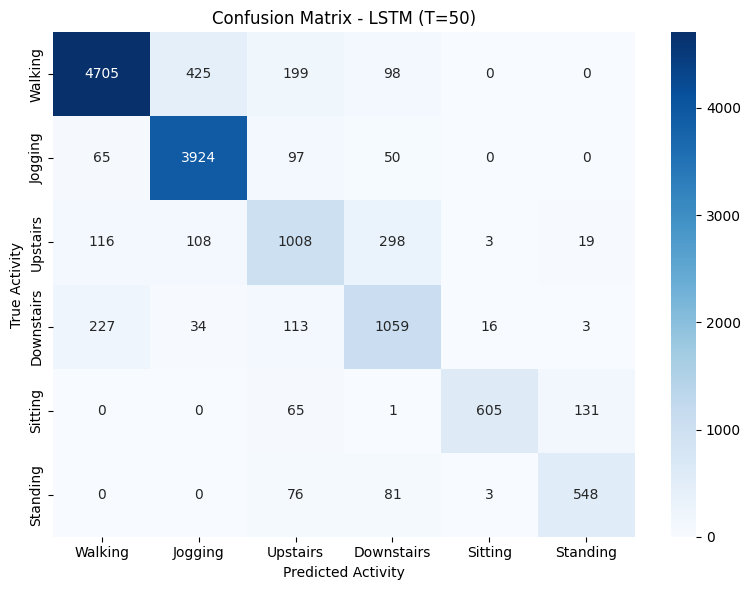


Statring PyTorch Training  LSTM (T=100)
Epoch 01/10 | Train Loss: 1.0146
Epoch 02/10 | Train Loss: 0.6869
Epoch 03/10 | Train Loss: 0.5828
Epoch 04/10 | Train Loss: 0.5057
Epoch 05/10 | Train Loss: 0.4401
Epoch 06/10 | Train Loss: 0.3895
Epoch 07/10 | Train Loss: 0.3362
Epoch 08/10 | Train Loss: 0.2754
Epoch 09/10 | Train Loss: 0.2384
Epoch 10/10 | Train Loss: 0.1972
PyTorch Total Training Time LSTM (T=100): 7.82 seconds

--- Evaluation Results for LSTM (T=100) ---
Accuracy: 77.97%
Macro-F1 Score: 0.7521

Per-Class F1 Scores:
  Walking: 0.7971
  Jogging: 0.8665
  Upstairs: 0.5435
  Downstairs: 0.6533
  Sitting: 0.8471
  Standing: 0.8053


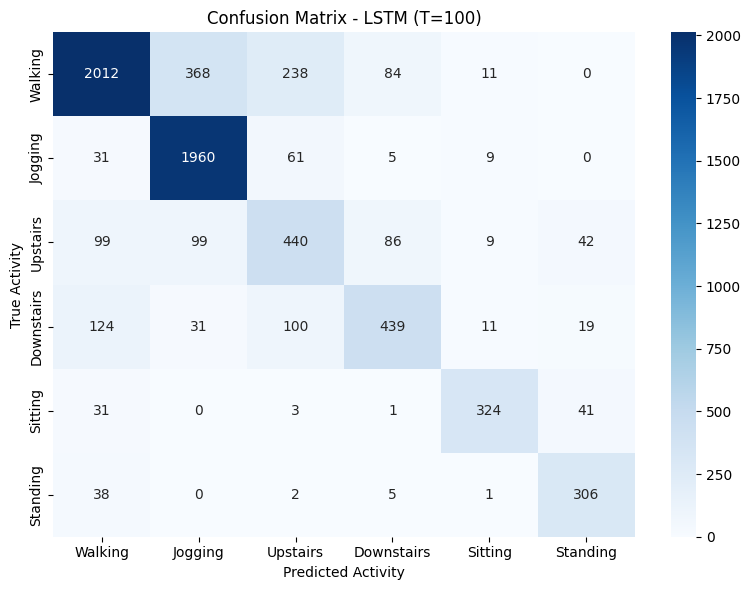


Statring PyTorch Training  LSTM (T=200)
Epoch 01/10 | Train Loss: 1.2486
Epoch 02/10 | Train Loss: 0.8887
Epoch 03/10 | Train Loss: 0.7398
Epoch 04/10 | Train Loss: 0.6890
Epoch 05/10 | Train Loss: 0.6642
Epoch 06/10 | Train Loss: 0.6583
Epoch 07/10 | Train Loss: 0.6086
Epoch 08/10 | Train Loss: 0.5466
Epoch 09/10 | Train Loss: 0.4923
Epoch 10/10 | Train Loss: 0.4724
PyTorch Total Training Time LSTM (T=200): 7.97 seconds

--- Evaluation Results for LSTM (T=200) ---
Accuracy: 70.62%
Macro-F1 Score: 0.6002

Per-Class F1 Scores:
  Walking: 0.7684
  Jogging: 0.8825
  Upstairs: 0.2716
  Downstairs: 0.3200
  Sitting: 0.8298
  Standing: 0.5290


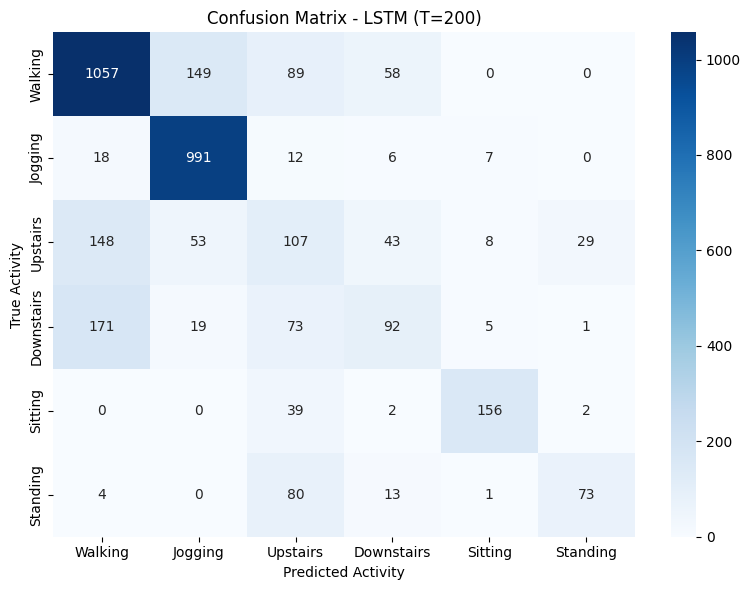


Statring PyTorch Training  LSTM (T=400)
Epoch 01/10 | Train Loss: 1.4476
Epoch 02/10 | Train Loss: 1.1719
Epoch 03/10 | Train Loss: 1.0636
Epoch 04/10 | Train Loss: 0.9473
Epoch 05/10 | Train Loss: 0.8521
Epoch 06/10 | Train Loss: 0.7958
Epoch 07/10 | Train Loss: 0.7925
Epoch 08/10 | Train Loss: 0.7398
Epoch 09/10 | Train Loss: 0.7084
Epoch 10/10 | Train Loss: 0.7345
PyTorch Total Training Time LSTM (T=400): 13.93 seconds

--- Evaluation Results for LSTM (T=400) ---
Accuracy: 61.58%
Macro-F1 Score: 0.4373

Per-Class F1 Scores:
  Walking: 0.6627
  Jogging: 0.8869
  Upstairs: 0.0000
  Downstairs: 0.0000
  Sitting: 0.8492
  Standing: 0.2251


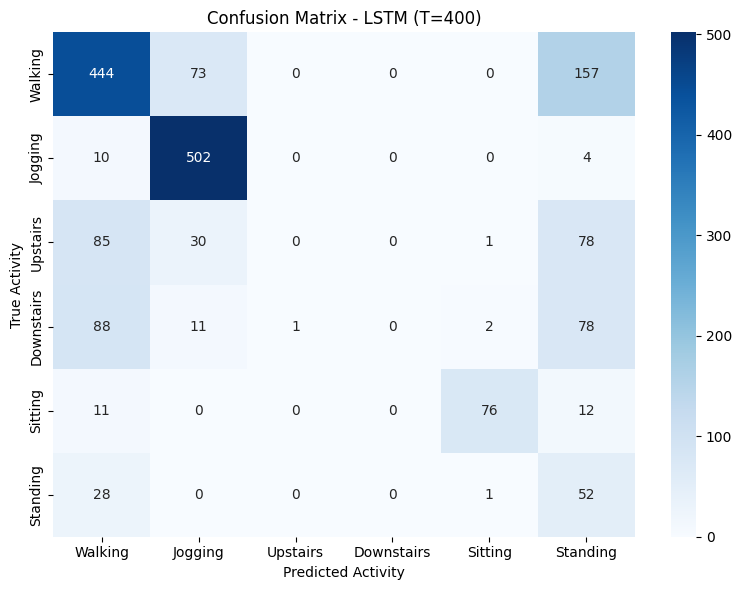


EXPERIMENT 2: Effect of Hidden Layer Size (hidden_dim)

Statring PyTorch Training  LSTM (hidden_dim=8)
Epoch 01/12 | Train Loss: 1.3361
Epoch 02/12 | Train Loss: 0.9704
Epoch 03/12 | Train Loss: 0.8606
Epoch 04/12 | Train Loss: 0.7839
Epoch 05/12 | Train Loss: 0.7474
Epoch 06/12 | Train Loss: 0.7040
Epoch 07/12 | Train Loss: 0.6620
Epoch 08/12 | Train Loss: 0.6658
Epoch 09/12 | Train Loss: 0.6227
Epoch 10/12 | Train Loss: 0.6161
Epoch 11/12 | Train Loss: 0.5984
Epoch 12/12 | Train Loss: 0.5731
PyTorch Total Training Time LSTM (hidden_dim=8): 4.83 seconds

--- Evaluation Results for LSTM (hidden_dim=8) ---
Accuracy: 72.39%
Macro-F1 Score: 0.5813

Per-Class F1 Scores:
  Walking: 0.7814
  Jogging: 0.8790
  Upstairs: 0.2810
  Downstairs: 0.0000
  Sitting: 0.8539
  Standing: 0.6923


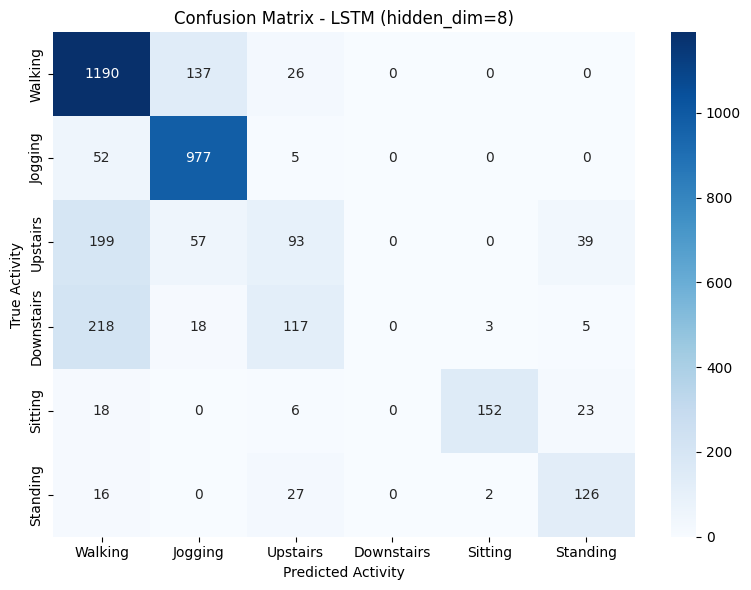


Statring PyTorch Training  LSTM (hidden_dim=16)
Epoch 01/12 | Train Loss: 1.2461
Epoch 02/12 | Train Loss: 0.9169
Epoch 03/12 | Train Loss: 0.8751
Epoch 04/12 | Train Loss: 0.7659
Epoch 05/12 | Train Loss: 0.7122
Epoch 06/12 | Train Loss: 0.6127
Epoch 07/12 | Train Loss: 0.5685
Epoch 08/12 | Train Loss: 0.5135
Epoch 09/12 | Train Loss: 0.4960
Epoch 10/12 | Train Loss: 0.4602
Epoch 11/12 | Train Loss: 0.4489
Epoch 12/12 | Train Loss: 0.4198
PyTorch Total Training Time LSTM (hidden_dim=16): 6.30 seconds

--- Evaluation Results for LSTM (hidden_dim=16) ---
Accuracy: 71.28%
Macro-F1 Score: 0.5868

Per-Class F1 Scores:
  Walking: 0.8381
  Jogging: 0.8592
  Upstairs: 0.4071
  Downstairs: 0.0053
  Sitting: 0.8295
  Standing: 0.5818


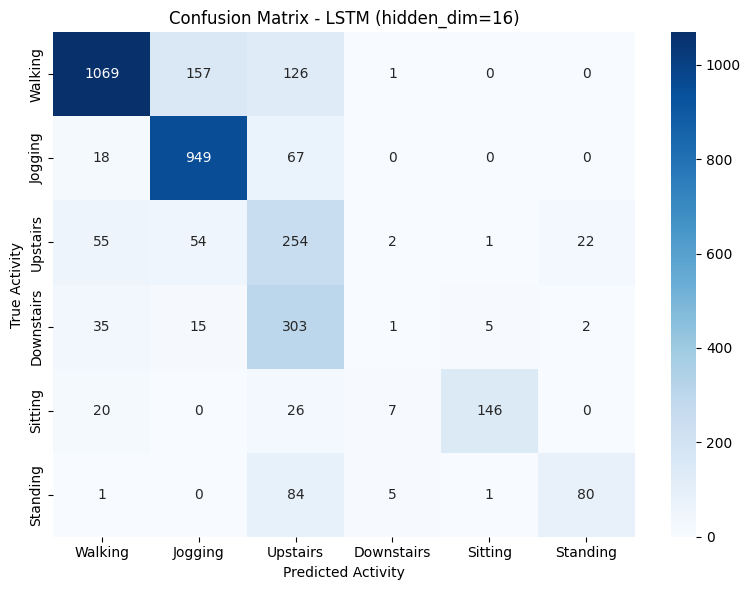


Statring PyTorch Training  LSTM (hidden_dim=32)
Epoch 01/12 | Train Loss: 1.2108
Epoch 02/12 | Train Loss: 0.8201
Epoch 03/12 | Train Loss: 0.7628
Epoch 04/12 | Train Loss: 0.6689
Epoch 05/12 | Train Loss: 0.6174
Epoch 06/12 | Train Loss: 0.5641
Epoch 07/12 | Train Loss: 0.5562
Epoch 08/12 | Train Loss: 0.4846
Epoch 09/12 | Train Loss: 0.4630
Epoch 10/12 | Train Loss: 0.4029
Epoch 11/12 | Train Loss: 0.3773
Epoch 12/12 | Train Loss: 0.3592
PyTorch Total Training Time LSTM (hidden_dim=32): 9.38 seconds

--- Evaluation Results for LSTM (hidden_dim=32) ---
Accuracy: 74.76%
Macro-F1 Score: 0.5982

Per-Class F1 Scores:
  Walking: 0.8414
  Jogging: 0.8968
  Upstairs: 0.4207
  Downstairs: 0.0000
  Sitting: 0.8708
  Standing: 0.5594


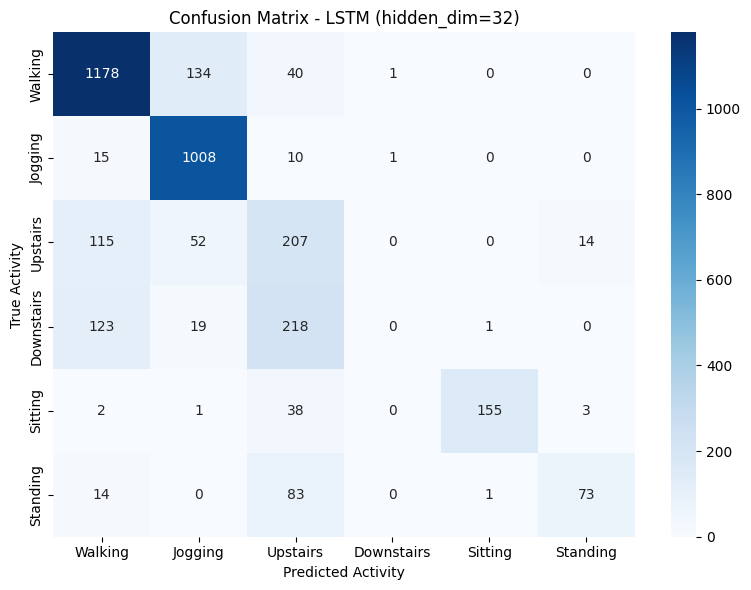


Statring PyTorch Training  LSTM (hidden_dim=64)
Epoch 01/12 | Train Loss: 1.2068
Epoch 02/12 | Train Loss: 0.9527
Epoch 03/12 | Train Loss: 0.8145
Epoch 04/12 | Train Loss: 0.7218
Epoch 05/12 | Train Loss: 0.5459
Epoch 06/12 | Train Loss: 0.4692
Epoch 07/12 | Train Loss: 0.4009
Epoch 08/12 | Train Loss: 0.3747
Epoch 09/12 | Train Loss: 0.3133
Epoch 10/12 | Train Loss: 0.2607
Epoch 11/12 | Train Loss: 0.2526
Epoch 12/12 | Train Loss: 0.2101
PyTorch Total Training Time LSTM (hidden_dim=64): 25.44 seconds

--- Evaluation Results for LSTM (hidden_dim=64) ---
Accuracy: 80.52%
Macro-F1 Score: 0.7779

Per-Class F1 Scores:
  Walking: 0.8640
  Jogging: 0.8785
  Upstairs: 0.5788
  Downstairs: 0.5832
  Sitting: 0.8771
  Standing: 0.8857


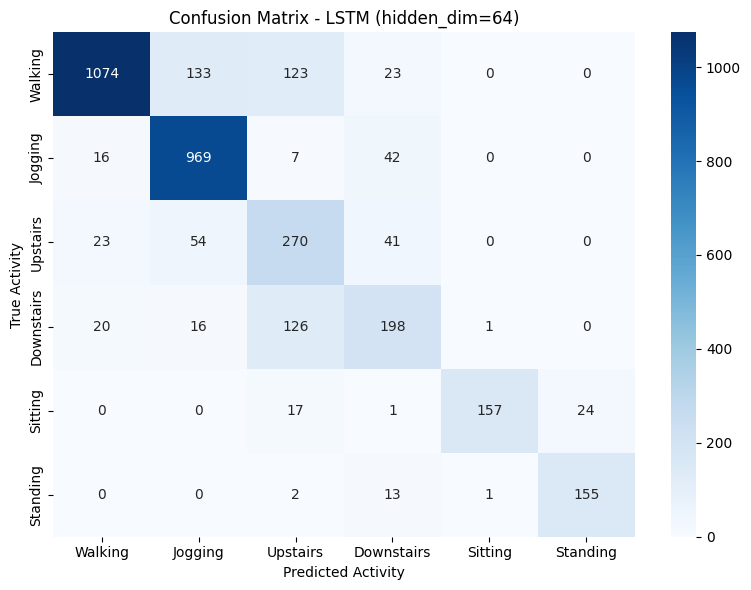


Statring PyTorch Training  LSTM (hidden_dim=128)
Epoch 01/12 | Train Loss: 1.2571
Epoch 02/12 | Train Loss: 1.0009
Epoch 03/12 | Train Loss: 0.7327
Epoch 04/12 | Train Loss: 0.5823
Epoch 05/12 | Train Loss: 0.4340
Epoch 06/12 | Train Loss: 0.3537
Epoch 07/12 | Train Loss: 0.2675
Epoch 08/12 | Train Loss: 0.2336
Epoch 09/12 | Train Loss: 0.2094
Epoch 10/12 | Train Loss: 0.1804
Epoch 11/12 | Train Loss: 0.1404
Epoch 12/12 | Train Loss: 0.1018
PyTorch Total Training Time LSTM (hidden_dim=128): 57.94 seconds

--- Evaluation Results for LSTM (hidden_dim=128) ---
Accuracy: 83.69%
Macro-F1 Score: 0.8013

Per-Class F1 Scores:
  Walking: 0.8768
  Jogging: 0.9064
  Upstairs: 0.6123
  Downstairs: 0.6902
  Sitting: 0.8372
  Standing: 0.8851


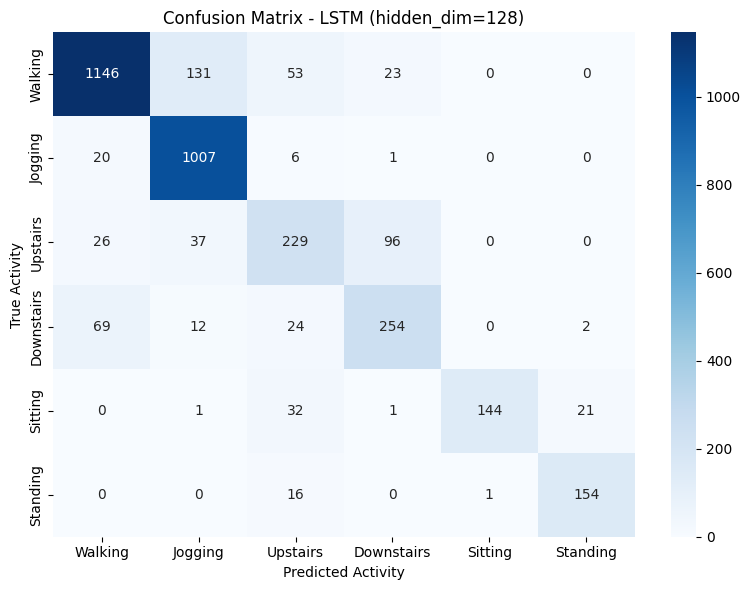


Statring PyTorch Training  LSTM (hidden_dim=256)
Epoch 01/12 | Train Loss: 1.1910
Epoch 02/12 | Train Loss: 0.8507
Epoch 03/12 | Train Loss: 1.3041
Epoch 04/12 | Train Loss: 0.9096
Epoch 05/12 | Train Loss: 0.6483
Epoch 06/12 | Train Loss: 0.9585
Epoch 07/12 | Train Loss: 0.9643
Epoch 08/12 | Train Loss: 0.7858
Epoch 09/12 | Train Loss: 0.6672
Epoch 10/12 | Train Loss: 0.6577
Epoch 11/12 | Train Loss: 0.6432
Epoch 12/12 | Train Loss: 0.5448
PyTorch Total Training Time LSTM (hidden_dim=256): 181.03 seconds

--- Evaluation Results for LSTM (hidden_dim=256) ---
Accuracy: 73.67%
Macro-F1 Score: 0.6302

Per-Class F1 Scores:
  Walking: 0.8133
  Jogging: 0.8822
  Upstairs: 0.2873
  Downstairs: 0.2346
  Sitting: 0.8348
  Standing: 0.7290


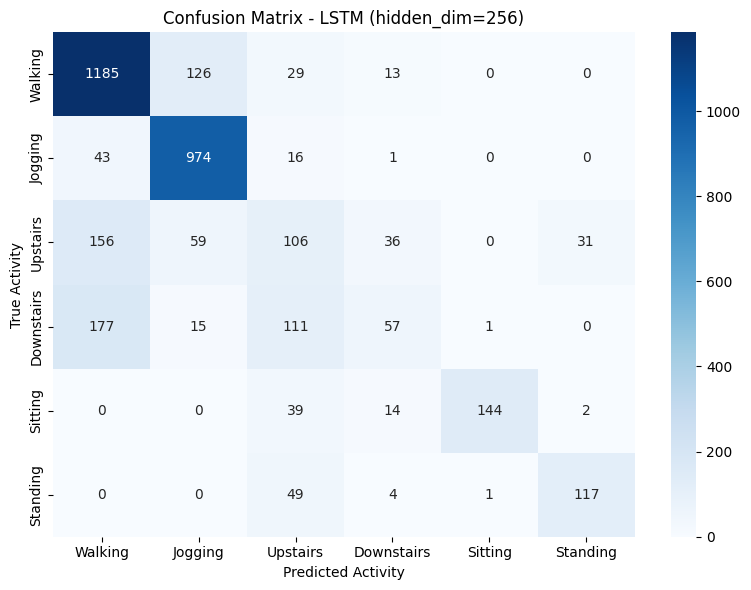

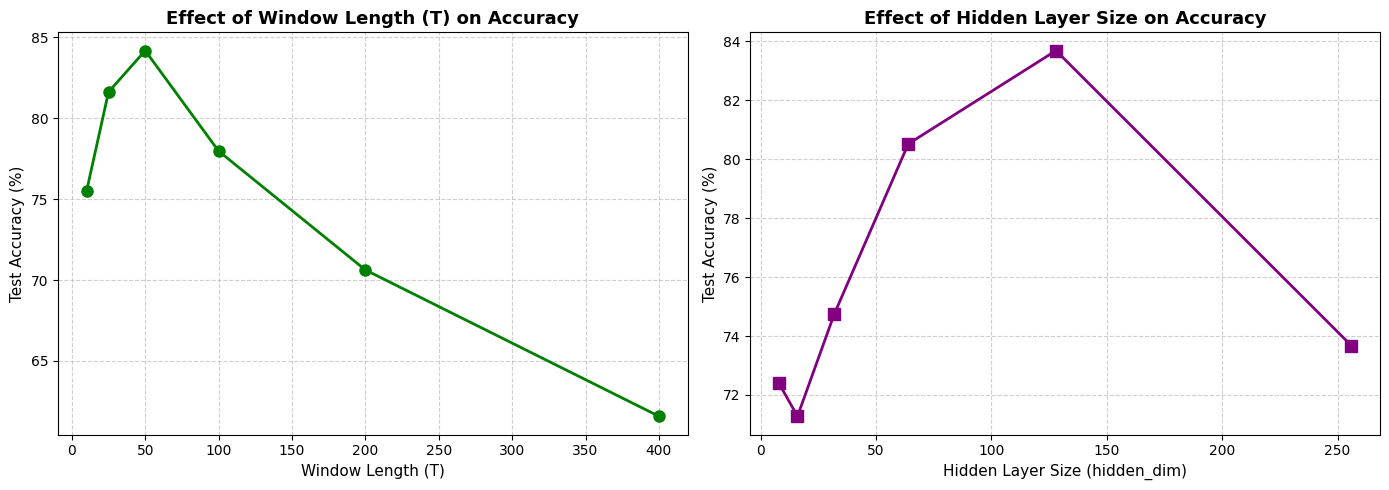

In [6]:
def run_sensitivity_experiments(train_dataset, test_dataset):
    print("\n" + "=" * 70)
    print("EXPERIMENT 1: Effect of Window Length (T)")
    print("=" * 70)

    window_sizes = [10, 25, 50, 100, 200, 400]
    win_accuracies = []

    for w_size in window_sizes:
        step = max(w_size // 2, 5)
        X_tr, y_tr = create_windows(train_dataset, window_size=w_size, step_size=step)
        X_te, y_te = create_windows(test_dataset, window_size=w_size, step_size=step)

        model = PyTorchLSTM(input_dim=3, hidden_dim=32, output_dim=6)
        _, acc, _ = train_pytorch_model(
            model,
            X_tr,
            y_tr,
            X_te,
            y_te,
            epochs=10,
            batch_size=64,
            lr=0.003,
            model_name=f"LSTM (T={w_size})",
        )
        win_accuracies.append(acc * 100)

    print("\n" + "=" * 70)
    print("EXPERIMENT 2: Effect of Hidden Layer Size (hidden_dim)")
    print("=" * 70)

    X_tr, y_tr = create_windows(train_dataset, window_size=200, step_size=100)
    X_te, y_te = create_windows(test_dataset, window_size=200, step_size=100)

    hidden_dims = [8, 16, 32, 64, 128, 256]
    hidden_accuracies = []

    for h_dim in hidden_dims:
        model = PyTorchLSTM(input_dim=3, hidden_dim=h_dim, output_dim=6)
        _, acc, _ = train_pytorch_model(
            model,
            X_tr,
            y_tr,
            X_te,
            y_te,
            epochs=12,
            batch_size=64,
            lr=0.005,
            model_name=f"LSTM (hidden_dim={h_dim})",
        )
        hidden_accuracies.append(acc * 100)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(
        window_sizes,
        win_accuracies,
        marker="o",
        color="green",
        linewidth=2,
        markersize=8,
    )
    ax1.set_title(
        "Effect of Window Length (T) on Accuracy", fontsize=13, fontweight="bold"
    )
    ax1.set_xlabel("Window Length (T)", fontsize=11)
    ax1.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax1.grid(True, linestyle="--", alpha=0.6)

    ax2.plot(
        hidden_dims,
        hidden_accuracies,
        marker="s",
        color="purple",
        linewidth=2,
        markersize=8,
    )
    ax2.set_title(
        "Effect of Hidden Layer Size on Accuracy", fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel("Hidden Layer Size (hidden_dim)", fontsize=11)
    ax2.set_ylabel("Test Accuracy (%)", fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


dataset, train_dataset, test_dataset = load_dataset()
run_sensitivity_experiments(train_dataset, test_dataset)